# 💧 Smart Water Quality Monitoring — Transformer Model

**Models:** TabTransformer vs FT-Transformer (Feature Tokenization Transformer)  
**Framework:** PyTorch  
**Standard:** BIS IS 10500:2012  
**Dataset:** NWMP 2019–2023

---
## Table of Contents
1. Stage 1 — Imports & Data Loading
2. Stage 2 — Data Cleaning
3. Stage 3 — BIS Label Generation
4. Stage 4 — WQI Computation
5. Stage 5 — Spatial Feature Engineering
6. Stage 6 — Temporal Feature Engineering
7. Stage 7 — Train-Test Split & PyTorch Datasets
8. Stage 8a — TabTransformer Model
9. Stage 8b — FT-Transformer Model
10. Stage 9 — Model Comparison & Evaluation
11. Stage 10 — SHAP Explainability
12. Stage 11 — Confidence Estimation
13. Stage 12 — Final Output & Save

---
## Stage 1 — Imports & Data Loading

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import pickle
import math
warnings.filterwarnings('ignore')

# ── Viz ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.model_selection import train_test_split
from scipy.stats import mode

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── SHAP ─────────────────────────────────────────────────────────────────────
import shap

# ── Settings ──────────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('✅ All libraries loaded!')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {DEVICE}')

✅ All libraries loaded!
   PyTorch version : 2.11.0+cpu
   Device          : cpu


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
FILE_PATH = 'Water_Quality_Combined_2019_2023.xlsx'
df_raw    = pd.read_excel(FILE_PATH)

print('✅ Dataset loaded!')
print(f'   Rows    : {len(df_raw):,}')
print(f'   Columns : {df_raw.shape[1]}')
print(f'   Years   : {sorted(df_raw["Year"].unique())}')
df_raw.head()

✅ Dataset loaded!
   Rows    : 3,109
   Columns : 21
   Years   : [2019, 2020, 2021, 2022, 2023]


,Year,Station_Code,Station_Name,Water_Body_Type,State,Temp_Min,Temp_Max,DO_Min,DO_Max,pH_Min,pH_Max,Conductivity_Min,Conductivity_Max,BOD_Min,BOD_Max,Nitrate_Min,Nitrate_Max,Fecal_Coliform_Min,Fecal_Coliform_Max,Total_Coliform_Min,Total_Coliform_Max
0,2019,1790,"PULICATE LAKE , NELLORE DIST",LAKE,ANDHRA PRADESH,18.00,28.00,4.90,5.50,6.70,8.20,21840.00,47890.00,2.20,2.80,0.46,2.80,3.00,4.00,210.00,1600.00
1,2019,2353,"KONDAKARLA-AAVA LAKE, PARAWADA PHARMA CITY, VI...",LAKE,ANDHRA PRADESH,24.00,30.00,5.00,6.80,7.00,8.50,714.00,1950.00,1.60,4.20,0.00,5.82,11.00,23.00,150.00,1100.00
2,2019,4368,"KOLLERU LAKE KOKKIRAYALANKA (V), KAILALUR (M)",LAKE,ANDHRA PRADESH,25.00,28.00,3.70,7.50,7.20,8.10,979.00,14730.00,1.70,5.40,0.00,3.47,4.00,20.00,150.00,1300.00
3,2019,4391,"CHENGAMBAKAM TANK IN SRI CITY SEZ, TIRUPATHI",TANK,ANDHRA PRADESH,25.00,36.00,3.20,6.10,6.80,7.90,228.00,1098.00,2.00,22.00,0.00,4.40,100.00,200.00,400.00,1400.00
4,2019,1529,"DEEPAR BEEL, ASSAM",LAKE,ASSAM,22.00,34.00,4.60,11.00,7.10,8.00,144.00,273.00,2.70,4.80,1.10,2.00,2.00,360.00,360.00,1500.00


---
## Stage 2 — Data Cleaning

In [3]:
# ── Average Min/Max for each parameter ───────────────────────────────────────
df = pd.DataFrame()
df['Year']            = df_raw['Year']
df['Station_Code']    = df_raw['Station_Code']
df['Station_Name']    = df_raw['Station_Name']
df['Water_Body_Type'] = df_raw['Water_Body_Type']
df['State']           = df_raw['State']

PARAM_PAIRS = {
    'Temperature'    : ('Temp_Min',           'Temp_Max'),
    'DO'             : ('DO_Min',             'DO_Max'),
    'pH'             : ('pH_Min',             'pH_Max'),
    'Conductivity'   : ('Conductivity_Min',   'Conductivity_Max'),
    'BOD'            : ('BOD_Min',            'BOD_Max'),
    'Nitrate'        : ('Nitrate_Min',        'Nitrate_Max'),
    'Fecal_Coliform' : ('Fecal_Coliform_Min', 'Fecal_Coliform_Max'),
    'Total_Coliform' : ('Total_Coliform_Min', 'Total_Coliform_Max'),
}
PARAM_COLS = list(PARAM_PAIRS.keys())

for param, (lo, hi) in PARAM_PAIRS.items():
    df[param] = (df_raw[lo].astype(float) + df_raw[hi].astype(float)) / 2

# ── Median imputation per station ─────────────────────────────────────────────
for col in PARAM_COLS:
    df[col] = df.groupby('Station_Code')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# ── IQR outlier removal ───────────────────────────────────────────────────────
rows_before = len(df)
for col in PARAM_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 3*IQR) & (df[col] <= Q3 + 3*IQR)]
df = df.reset_index(drop=True)

print('✅ Cleaning done!')
print(f'   Rows before : {rows_before:,}')
print(f'   Rows after  : {len(df):,}')
print(f'   Removed     : {rows_before - len(df):,}')

✅ Cleaning done!
   Rows before : 3,109
   Rows after  : 1,990
   Removed     : 1,119


---
## Stage 3 — BIS Label Generation

In [4]:
# ── BIS IS 10500:2012 thresholds ──────────────────────────────────────────────
BIS = {
    'pH'             : ('range',  6.5,  8.5,  9.2),
    'DO'             : ('higher', 6.0,  4.0,  None),
    'BOD'            : ('lower',  2.0,  5.0,  None),
    'Nitrate'        : ('lower',  45.0, 100.0, None),
    'Conductivity'   : ('lower',  750.0, 3000.0, None),
    'Fecal_Coliform' : ('lower',  2.2,  500.0, None),
    'Total_Coliform' : ('lower',  10.0, 500.0, None),
    'Temperature'    : ('lower',  25.0, 40.0, None),
}
CLASS_NAMES = {0: 'Safe', 1: 'Marginal', 2: 'Unsafe'}

def classify_param(value, rule):
    kind = rule[0]
    if pd.isna(value): return 0
    if kind == 'higher':
        return 0 if value >= rule[1] else (1 if value >= rule[2] else 2)
    elif kind == 'range':
        return 0 if rule[1] <= value <= rule[2] else (1 if rule[1] <= value <= rule[3] else 2)
    else:
        return 0 if value <= rule[1] else (1 if value <= rule[2] else 2)

def classify_sample(row):
    return max(classify_param(row[p], BIS[p]) for p in BIS if p in row.index)

df['BIS_Class'] = df.apply(classify_sample, axis=1)
df['BIS_Label'] = df['BIS_Class'].map(CLASS_NAMES)

print('✅ BIS labels created!')
print(df['BIS_Label'].value_counts())

✅ BIS labels created!
BIS_Label
Unsafe      1272
Marginal     715
Safe           3
Name: count, dtype: int64


---
## Stage 4 — WQI Computation

In [5]:
WQI_LIMITS = {
    'pH': 8.5, 'DO': 4.0, 'BOD': 5.0, 'Nitrate': 100.0,
    'Conductivity': 3000.0, 'Fecal_Coliform': 500.0, 'Total_Coliform': 500.0,
}

def compute_wqi(row):
    tw, ww = 0, 0
    for p, lim in WQI_LIMITS.items():
        if pd.isna(row[p]) or lim == 0: continue
        wi  = 1 / lim
        qi  = (abs(row[p]) / lim) * 100
        tw += wi * qi
        ww += wi
    return round(tw / ww, 2) if ww > 0 else np.nan

def wqi_cat(w):
    if pd.isna(w):  return 'Unknown'
    elif w <= 50:   return 'Excellent'
    elif w <= 100:  return 'Good'
    elif w <= 200:  return 'Poor'
    elif w <= 300:  return 'Very Poor'
    else:           return 'Unsuitable'

df['WQI']          = df.apply(compute_wqi, axis=1)
df['WQI_Category'] = df['WQI'].apply(wqi_cat)

print('✅ WQI computed!')
print(f'   Range : {df["WQI"].min():.1f} – {df["WQI"].max():.1f}')
print(f'   Mean  : {df["WQI"].mean():.1f}')

✅ WQI computed!
   Range : 32.4 – 275.7
   Mean  : 109.1


---
## Stage 5 — Spatial Feature Engineering

In [6]:
station_avg  = df.groupby('Station_Code')['WQI'].mean().rename('Station_Avg_WQI')
df           = df.merge(station_avg, on='Station_Code', how='left')

station_viol = (df.groupby('Station_Code')['BIS_Class']
                .apply(lambda x: (x == 2).mean()).rename('Station_Violation_Rate'))
df           = df.merge(station_viol, on='Station_Code', how='left')

state_avg    = df.groupby('State')['WQI'].mean().rename('State_Avg_WQI')
df           = df.merge(state_avg, on='State', how='left')

df['WQI_Deviation_from_State'] = df['WQI'] - df['State_Avg_WQI']

print('✅ Spatial features done!')
print('   Station_Avg_WQI, Station_Violation_Rate, State_Avg_WQI, WQI_Deviation_from_State')

✅ Spatial features done!
   Station_Avg_WQI, Station_Violation_Rate, State_Avg_WQI, WQI_Deviation_from_State


---
## Stage 6 — Temporal Feature Engineering

In [7]:
df = df.sort_values(['Station_Code', 'Year']).reset_index(drop=True)

df['WQI_Lag1']    = df.groupby('Station_Code')['WQI'].shift(1)
df['WQI_Rolling3']= (df.groupby('Station_Code')['WQI']
                     .transform(lambda x: x.rolling(3, min_periods=1).mean()))
df['WQI_Trend']   = df['WQI'] - df['WQI_Lag1']
df['Pollution_Growth_Rate'] = ((df['WQI'] - df['WQI_Lag1'])
                               / df['WQI_Lag1'].replace(0, np.nan)) * 100

for col in ['WQI_Lag1', 'WQI_Trend', 'Pollution_Growth_Rate']:
    df[col] = df[col].fillna(df[col].median())

print('✅ Temporal features done!')
print(f'   Final shape: {df.shape}')

✅ Temporal features done!
   Final shape: (1990, 25)


---
## Stage 7 — Train-Test Split & PyTorch Datasets

In [8]:
# ── Feature and target definition ─────────────────────────────────────────────
FEATURE_COLS = [
    'Temperature', 'DO', 'pH', 'Conductivity',
    'BOD', 'Nitrate', 'Fecal_Coliform', 'Total_Coliform',
    'Station_Avg_WQI', 'Station_Violation_Rate',
    'State_Avg_WQI', 'WQI_Deviation_from_State',
    'WQI_Lag1', 'WQI_Rolling3', 'WQI_Trend', 'Pollution_Growth_Rate',
    'WQI',
]
TARGET_COL = 'BIS_Class'
N_FEATURES = len(FEATURE_COLS)
N_CLASSES  = 3

# ── Time-aware split ──────────────────────────────────────────────────────────
train_df = df[df['Year'] <= 2022].copy()
test_df  = df[df['Year'] == 2023].copy()

X_train_raw = train_df[FEATURE_COLS].values.astype(np.float32)
y_train_raw = train_df[TARGET_COL].values.astype(np.int64)
X_test_raw  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test_raw  = test_df[TARGET_COL].values.astype(np.int64)

# ── Standardize features ──────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_sc   = scaler.transform(X_test_raw).astype(np.float32)

print('✅ Split done!')
print(f'   Train : {X_train_sc.shape}')
print(f'   Test  : {X_test_sc.shape}')
print(f'   Train class dist: {np.bincount(y_train_raw)}')
print(f'   Test  class dist: {np.bincount(y_test_raw)}')

✅ Split done!
   Train : (1500, 17)
   Test  : (490, 17)
   Train class dist: [  1 576 923]
   Test  class dist: [  2 139 349]


In [9]:
# ── PyTorch Dataset class ─────────────────────────────────────────────────────
class WaterDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE   = 64
train_ds     = WaterDataset(X_train_sc, y_train_raw)
test_ds      = WaterDataset(X_test_sc,  y_test_raw)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print('✅ DataLoaders ready!')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test  batches : {len(test_loader)}')

✅ DataLoaders ready!
   Train batches : 24
   Test  batches : 8


---
## Stage 8a — TabTransformer Model

TabTransformer applies Multi-Head Self-Attention across feature embeddings.
Each feature is projected into an embedding space, then Transformer encoder layers
learn relationships between features. Final MLP head produces class probabilities.

In [10]:
# ── TabTransformer Architecture ───────────────────────────────────────────────
class TabTransformer(nn.Module):
    """
    TabTransformer for tabular classification.
    Each feature → linear embedding → Transformer encoder → MLP head.
    """
    def __init__(self,
                 n_features,
                 n_classes,
                 dim         = 64,    # embedding dimension
                 n_heads     = 8,     # attention heads
                 n_layers    = 4,     # transformer encoder layers
                 ffn_dim     = 256,   # feedforward network dimension
                 dropout     = 0.1):
        super().__init__()

        # Project each feature scalar → embedding vector of size dim
        self.feature_embed = nn.Linear(1, dim)

        # Learnable positional encoding (one per feature)
        self.pos_embed = nn.Parameter(torch.randn(1, n_features, dim))

        # Transformer encoder stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = dim,
            nhead           = n_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,    # Pre-LayerNorm (more stable)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # MLP classification head
        self.head = nn.Sequential(
            nn.LayerNorm(dim * n_features),
            nn.Linear(dim * n_features, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_features)
        x = x.unsqueeze(-1)                    # (batch, n_features, 1)
        x = self.feature_embed(x)              # (batch, n_features, dim)
        x = x + self.pos_embed                 # add positional encoding
        x = self.transformer(x)                # (batch, n_features, dim)
        x = x.flatten(1)                       # (batch, n_features * dim)
        return self.head(x)                    # (batch, n_classes)


tab_model = TabTransformer(
    n_features = N_FEATURES,
    n_classes  = N_CLASSES,
    dim        = 64,
    n_heads    = 8,
    n_layers   = 4,
    ffn_dim    = 256,
    dropout    = 0.1,
).to(DEVICE)

total_params = sum(p.numel() for p in tab_model.parameters() if p.requires_grad)
print('✅ TabTransformer built!')
print(f'   Trainable parameters : {total_params:,}')
print(tab_model)

✅ TabTransformer built!
   Trainable parameters : 515,395
TabTransformer(
  (feature_embed): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((1088,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=1088, out_features=256, bias=True)
    (

In [11]:
# ── Training utility functions ────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, epochs=80, lr=3e-4, model_name='Model'):
    # Class weights to handle imbalance
    class_counts = np.bincount(y_train_raw)
    class_weights = torch.tensor(
        1.0 / class_counts, dtype=torch.float32
    ).to(DEVICE)
    class_weights = class_weights / class_weights.sum() * N_CLASSES

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc  = 0
    best_state    = None

    print(f'\n🚀 Training {model_name} for {epochs} epochs...')
    print('-' * 65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = eval_epoch(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
                  f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

    # Restore best weights
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'\n✅ {model_name} training complete!')
    print(f'   Best Val Accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return history

print('✅ Training utilities defined!')

✅ Training utilities defined!


In [12]:
# ── Train TabTransformer ──────────────────────────────────────────────────────
tab_history = train_model(
    tab_model, train_loader, test_loader,
    epochs=80, lr=3e-4, model_name='TabTransformer'
)


🚀 Training TabTransformer for 80 epochs...
-----------------------------------------------------------------
  Epoch   1/80 | Train Loss: 0.5909 Acc: 0.8100 | Val Loss: 0.8385 Acc: 0.9694
  Epoch  10/80 | Train Loss: 0.2769 Acc: 0.9887 | Val Loss: 0.7967 Acc: 0.9857
  Epoch  20/80 | Train Loss: 0.2067 Acc: 0.9940 | Val Loss: 0.7564 Acc: 0.9816
  Epoch  30/80 | Train Loss: 0.0652 Acc: 0.9960 | Val Loss: 0.7796 Acc: 0.9837
  Epoch  40/80 | Train Loss: 0.0235 Acc: 0.9980 | Val Loss: 1.0313 Acc: 0.9878
  Epoch  50/80 | Train Loss: 0.0073 Acc: 1.0000 | Val Loss: 1.1024 Acc: 0.9898
  Epoch  60/80 | Train Loss: 0.0040 Acc: 1.0000 | Val Loss: 1.0948 Acc: 0.9878
  Epoch  70/80 | Train Loss: 0.0021 Acc: 0.9993 | Val Loss: 1.1503 Acc: 0.9898
  Epoch  80/80 | Train Loss: 0.0022 Acc: 1.0000 | Val Loss: 1.1397 Acc: 0.9898

✅ TabTransformer training complete!
   Best Val Accuracy : 0.9918 (99.18%)


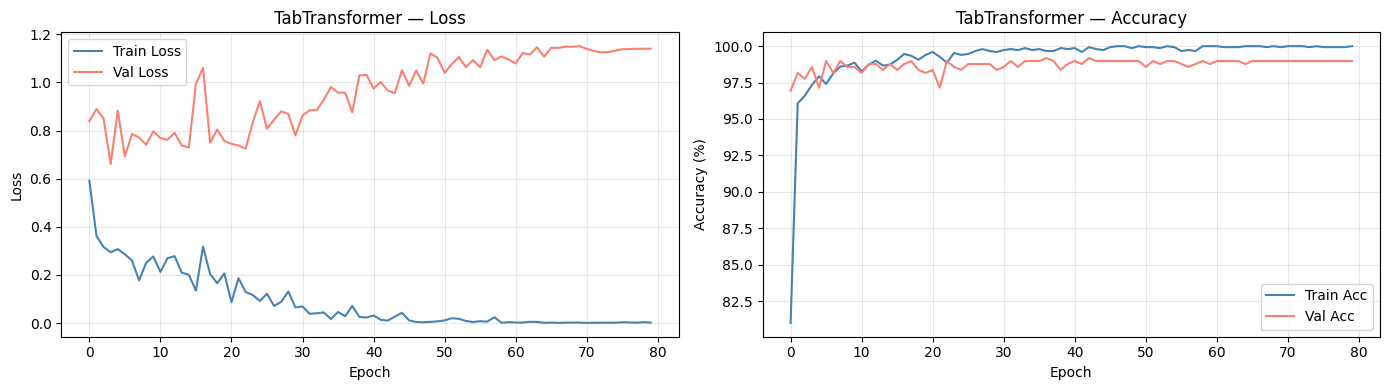

In [13]:
# ── Plot TabTransformer training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tab_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(tab_history['val_loss'],   label='Val Loss',   color='salmon')
axes[0].set_title('TabTransformer — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in tab_history['train_acc']], label='Train Acc', color='steelblue')
axes[1].plot([a*100 for a in tab_history['val_acc']],   label='Val Acc',   color='salmon')
axes[1].set_title('TabTransformer — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Stage 8b — FT-Transformer Model

FT-Transformer (Feature Tokenization Transformer) improves on TabTransformer by:
1. Using a dedicated linear tokenizer per feature (separate weights per feature)
2. Adding a learnable [CLS] token whose final representation is used for classification
3. Applying attention across all feature tokens + CLS token simultaneously

In [14]:
# ── FT-Transformer Architecture ───────────────────────────────────────────────
class FeatureTokenizer(nn.Module):
    """
    Projects each feature using its OWN dedicated linear layer.
    This is the key difference from TabTransformer which shares weights.
    """
    def __init__(self, n_features, dim):
        super().__init__()
        # Separate weight and bias per feature
        self.weight = nn.Parameter(torch.randn(n_features, dim))
        self.bias   = nn.Parameter(torch.zeros(n_features, dim))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        # x: (batch, n_features)
        # output: (batch, n_features, dim)
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class FTTransformer(nn.Module):
    """
    Feature Tokenization Transformer.
    Per-feature tokenization → CLS token prepended → Transformer → CLS output → classifier.
    """
    def __init__(self,
                 n_features,
                 n_classes,
                 dim         = 64,
                 n_heads     = 8,
                 n_layers    = 6,     # deeper than TabTransformer
                 ffn_dim     = 256,
                 dropout     = 0.1):
        super().__init__()

        # Per-feature tokenizer (key novelty)
        self.tokenizer = FeatureTokenizer(n_features, dim)

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = dim,
            nhead           = n_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm        = nn.LayerNorm(dim)

        # Classification head (uses only CLS token output)
        self.head = nn.Sequential(
            nn.Linear(dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # Tokenize features
        tokens = self.tokenizer(x)                              # (B, n_features, dim)

        # Prepend CLS token
        cls    = self.cls_token.expand(x.size(0), -1, -1)      # (B, 1, dim)
        tokens = torch.cat([cls, tokens], dim=1)                # (B, n_features+1, dim)

        # Transformer
        out    = self.transformer(tokens)                       # (B, n_features+1, dim)
        out    = self.norm(out)

        # Use CLS token (index 0) for classification
        cls_out = out[:, 0, :]                                  # (B, dim)
        return self.head(cls_out)                               # (B, n_classes)


ft_model = FTTransformer(
    n_features = N_FEATURES,
    n_classes  = N_CLASSES,
    dim        = 64,
    n_heads    = 8,
    n_layers   = 6,
    ffn_dim    = 256,
    dropout    = 0.1,
).to(DEVICE)

total_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print('✅ FT-Transformer built!')
print(f'   Trainable parameters : {total_params:,}')
print(ft_model)

✅ FT-Transformer built!
   Trainable parameters : 310,979
FTTransformer(
  (tokenizer): FeatureTokenizer()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): D

In [15]:
# ── Train FT-Transformer ──────────────────────────────────────────────────────
ft_history = train_model(
    ft_model, train_loader, test_loader,
    epochs=80, lr=3e-4, model_name='FT-Transformer'
)


🚀 Training FT-Transformer for 80 epochs...
-----------------------------------------------------------------
  Epoch   1/80 | Train Loss: 0.5972 Acc: 0.8900 | Val Loss: 0.5165 Acc: 0.9755
  Epoch  10/80 | Train Loss: 0.2089 Acc: 0.9880 | Val Loss: 0.6037 Acc: 0.9857
  Epoch  20/80 | Train Loss: 0.1505 Acc: 0.9953 | Val Loss: 0.7002 Acc: 0.9878
  Epoch  30/80 | Train Loss: 0.1699 Acc: 0.9960 | Val Loss: 0.9136 Acc: 0.9878
  Epoch  40/80 | Train Loss: 0.0160 Acc: 0.9993 | Val Loss: 0.8174 Acc: 0.9878
  Epoch  50/80 | Train Loss: 0.0010 Acc: 1.0000 | Val Loss: 1.0853 Acc: 0.9857
  Epoch  60/80 | Train Loss: 0.0003 Acc: 1.0000 | Val Loss: 1.1246 Acc: 0.9857
  Epoch  70/80 | Train Loss: 0.0003 Acc: 1.0000 | Val Loss: 1.0599 Acc: 0.9878
  Epoch  80/80 | Train Loss: 0.0003 Acc: 1.0000 | Val Loss: 1.0846 Acc: 0.9878

✅ FT-Transformer training complete!
   Best Val Accuracy : 0.9898 (98.98%)


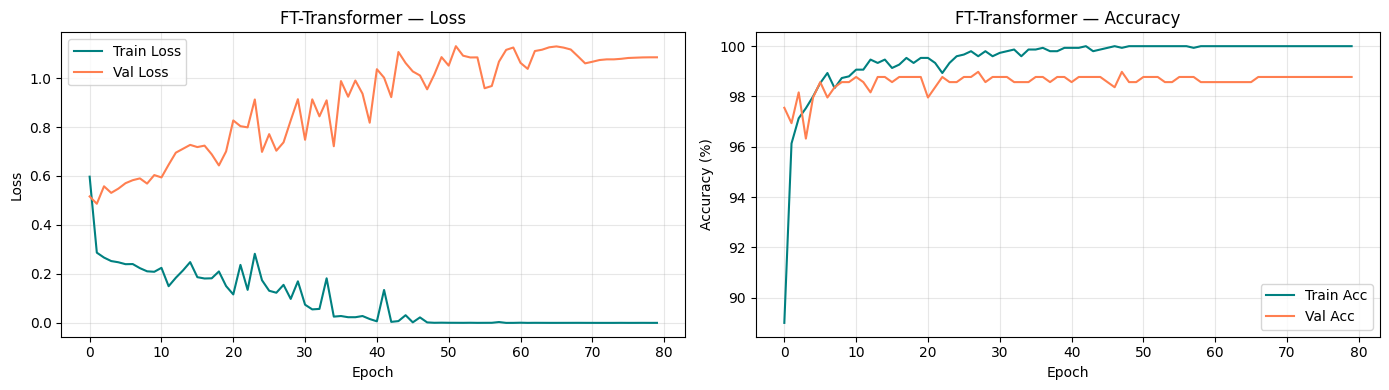

In [16]:
# ── Plot FT-Transformer training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ft_history['train_loss'], label='Train Loss', color='teal')
axes[0].plot(ft_history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('FT-Transformer — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in ft_history['train_acc']], label='Train Acc', color='teal')
axes[1].plot([a*100 for a in ft_history['val_acc']],   label='Val Acc',   color='coral')
axes[1].set_title('FT-Transformer — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Stage 9 — Model Comparison & Evaluation

In [17]:
# ── Get predictions from both models ─────────────────────────────────────────
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = F.softmax(logits, dim=1).cpu().numpy()
        preds   = logits.argmax(1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())
    return (np.concatenate(all_preds),
            np.concatenate(all_probs),
            np.concatenate(all_labels))

tab_preds, tab_proba, y_true = get_predictions(tab_model, test_loader)
ft_preds,  ft_proba,  _      = get_predictions(ft_model,  test_loader)

tab_acc = accuracy_score(y_true, tab_preds)
ft_acc  = accuracy_score(y_true, ft_preds)

print('=' * 55)
print('         MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'  TabTransformer  Accuracy : {tab_acc*100:.2f}%')
print(f'  FT-Transformer  Accuracy : {ft_acc*100:.2f}%')
winner = 'FT-Transformer' if ft_acc >= tab_acc else 'TabTransformer'
print(f'  Winner                   : {winner}')
print('=' * 55)

         MODEL COMPARISON SUMMARY
  TabTransformer  Accuracy : 99.18%
  FT-Transformer  Accuracy : 98.98%
  Winner                   : TabTransformer


In [18]:
# ── Detailed classification reports ───────────────────────────────────────────
print('📊 TabTransformer Classification Report:')
print(classification_report(y_true, tab_preds,
                             target_names=['Safe', 'Marginal', 'Unsafe']))

print('📊 FT-Transformer Classification Report:')
print(classification_report(y_true, ft_preds,
                             target_names=['Safe', 'Marginal', 'Unsafe']))

📊 TabTransformer Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      0.50      0.67         2
    Marginal       0.97      1.00      0.99       139
      Unsafe       1.00      0.99      1.00       349

    accuracy                           0.99       490
   macro avg       0.99      0.83      0.88       490
weighted avg       0.99      0.99      0.99       490

📊 FT-Transformer Classification Report:
              precision    recall  f1-score   support

        Safe       0.00      0.00      0.00         2
    Marginal       0.97      0.99      0.98       139
      Unsafe       1.00      0.99      1.00       349

    accuracy                           0.99       490
   macro avg       0.66      0.66      0.66       490
weighted avg       0.99      0.99      0.99       490



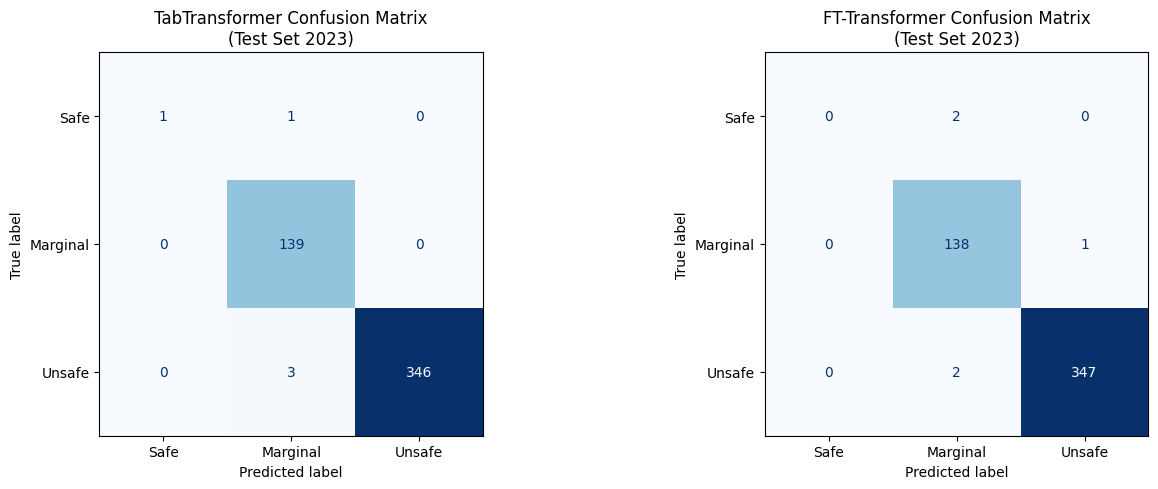

In [19]:
# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [tab_preds, ft_preds],
    ['TabTransformer', 'FT-Transformer']
):
    cm   = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Marginal', 'Unsafe'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} Confusion Matrix\n(Test Set 2023)', fontsize=12)

plt.tight_layout()
plt.show()

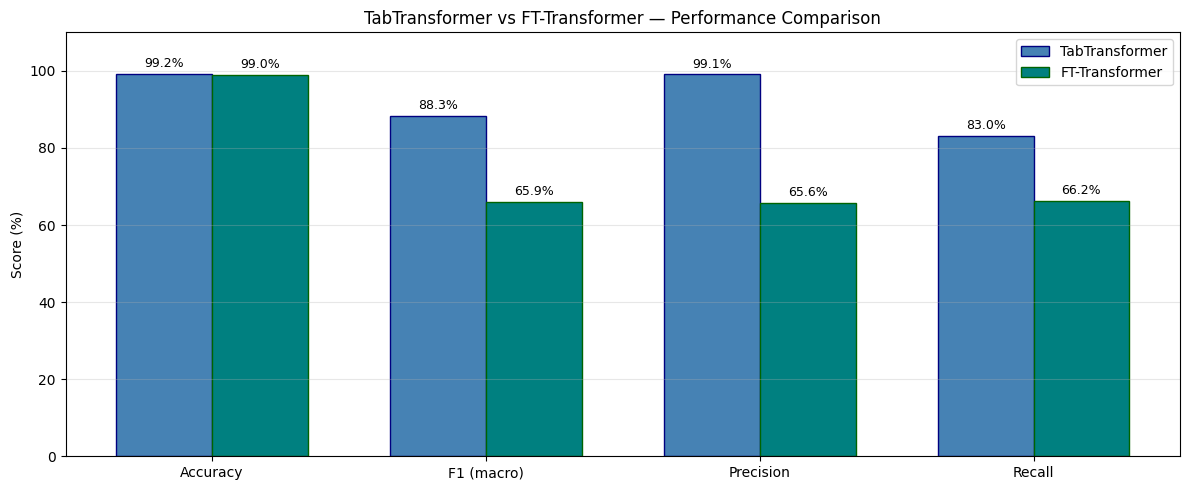

In [20]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Accuracy' : [tab_acc,
                  ft_acc],
    'F1 (macro)': [f1_score(y_true, tab_preds, average='macro'),
                   f1_score(y_true, ft_preds,  average='macro')],
    'Precision' : [precision_score(y_true, tab_preds, average='macro'),
                   precision_score(y_true, ft_preds,  average='macro')],
    'Recall'    : [recall_score(y_true, tab_preds, average='macro'),
                   recall_score(y_true, ft_preds,  average='macro')],
}

x     = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, [v[0]*100 for v in metrics.values()],
               width, label='TabTransformer', color='steelblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, [v[1]*100 for v in metrics.values()],
               width, label='FT-Transformer', color='teal', edgecolor='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel('Score (%)')
ax.set_title('TabTransformer vs FT-Transformer — Performance Comparison')
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
# ── Select best model for remaining stages ────────────────────────────────────
if ft_acc >= tab_acc:
    best_model  = ft_model
    best_preds  = ft_preds
    best_proba  = ft_proba
    best_name   = 'FT-Transformer'
else:
    best_model  = tab_model
    best_preds  = tab_preds
    best_proba  = tab_proba
    best_name   = 'TabTransformer'

print(f'✅ Best model selected: {best_name} ({max(tab_acc, ft_acc)*100:.2f}%)')

✅ Best model selected: TabTransformer (99.18%)


## Stage 9b- Baseline model comparison

In [22]:
# ═══════════════════════════════════════════════════════════════
# Stage 9b — Baseline Model Comparison
# ═══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

In [23]:
# ── Train XGBoost ─────────────────────────────────────────────
print('⏳ Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    objective         = 'multi:softprob',
    num_class         = 3,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)
xgb_model.fit(X_train_sc, y_train_raw)
xgb_preds = xgb_model.predict(X_test_sc)
xgb_acc   = accuracy_score(y_test_raw, xgb_preds)
print(f'✅ XGBoost done! Accuracy: {xgb_acc*100:.2f}%')

⏳ Training XGBoost...
✅ XGBoost done! Accuracy: 99.39%


In [24]:
# ── Train Random Forest ───────────────────────────────────────
print('⏳ Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 12,
    random_state = 42,
    n_jobs       = -1,
    class_weight = 'balanced',
)
rf_model.fit(X_train_sc, y_train_raw)
rf_preds = rf_model.predict(X_test_sc)
rf_acc   = accuracy_score(y_test_raw, rf_preds)
print(f'✅ Random Forest done! Accuracy: {rf_acc*100:.2f}%')

⏳ Training Random Forest...
✅ Random Forest done! Accuracy: 99.39%


In [25]:
# ── Train MLP (sklearn) ───────────────────────────────────────
print('⏳ Training MLP...')
mlp_model = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64),
    activation         = 'relu',
    solver             = 'adam',
    learning_rate_init = 3e-4,
    max_iter           = 200,
    random_state       = 42,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 15,
)
mlp_model.fit(X_train_sc, y_train_raw)
mlp_preds = mlp_model.predict(X_test_sc)
mlp_acc   = accuracy_score(y_test_raw, mlp_preds)
print(f'✅ MLP done! Accuracy: {mlp_acc*100:.2f}%')

⏳ Training MLP...
✅ MLP done! Accuracy: 97.35%


In [26]:
# ── Full Comparison Table ─────────────────────────────────────
all_models = {
    'TabTransformer' : (tab_preds,  y_true),
    'FT-Transformer' : (ft_preds,   y_true),
    'XGBoost'        : (xgb_preds,  y_test_raw),
    'Random Forest'  : (rf_preds,   y_test_raw),
    'MLP'            : (mlp_preds,  y_test_raw),
}

rows = []
for name, (preds, labels) in all_models.items():
    rows.append({
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(labels, preds) * 100, 2),
        'F1 (macro)' : round(f1_score(labels, preds, average='macro') * 100, 2),
        'Precision'  : round(precision_score(labels, preds, average='macro') * 100, 2),
        'Recall'     : round(recall_score(labels, preds, average='macro') * 100, 2),
        'Type'       : 'Transformer' if 'Transformer' in name else 'Baseline',
    })

comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print('=' * 65)
print('              FULL MODEL COMPARISON TABLE')
print('=' * 65)
print(comparison_df.to_string(index=False))
print('=' * 65)

              FULL MODEL COMPARISON TABLE
         Model  Accuracy  F1 (macro)  Precision  Recall        Type
       XGBoost     99.39       66.26      65.96   66.57    Baseline
 Random Forest     99.39       66.26      65.96   66.57    Baseline
TabTransformer     99.18       88.27      99.07   83.05 Transformer
FT-Transformer     98.98       65.93      65.63   66.24 Transformer
           MLP     97.35       64.59      64.43   64.75    Baseline


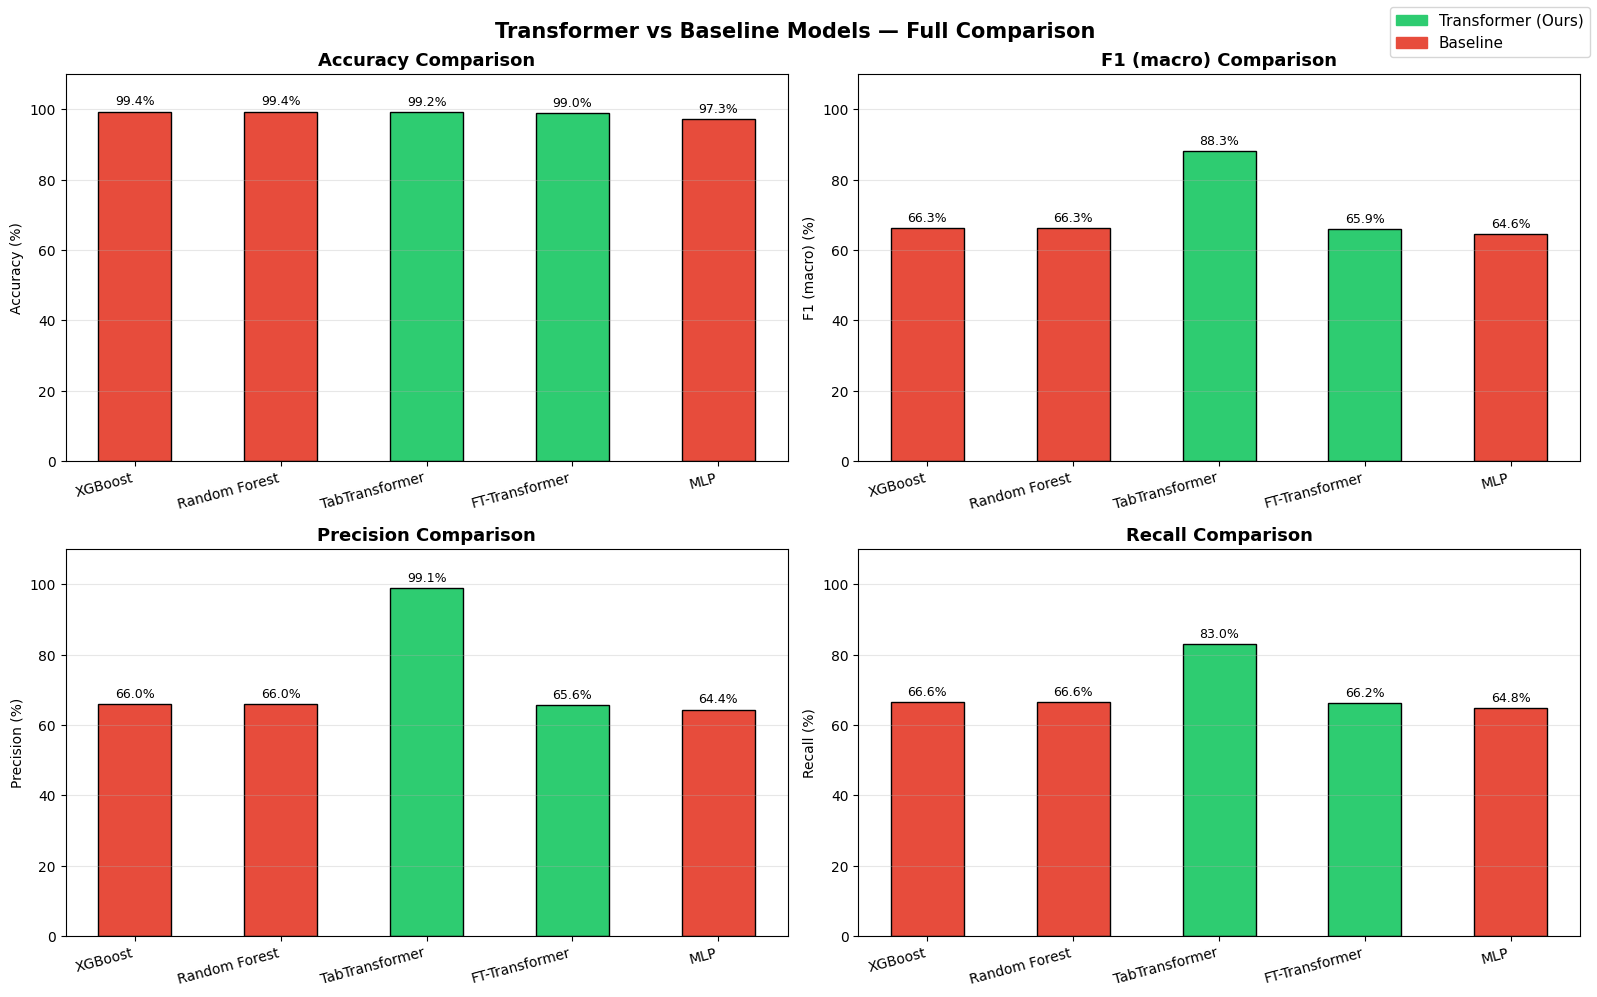

In [27]:
# ── Comparison Bar Chart — All 5 Models ──────────────────────
metrics_to_plot = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
x     = np.arange(len(comparison_df))
width = 0.2
colors = ['#2ecc71' if t == 'Transformer' else '#e74c3c'
          for t in comparison_df['Type']]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(x, comparison_df[metric], color=colors, edgecolor='black', width=0.5)
    axes[i].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
    axes[i].set_ylabel(f'{metric} (%)')
    axes[i].set_ylim(0, 110)
    axes[i].grid(axis='y', alpha=0.3)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Transformer (Ours)'),
          Patch(color='#e74c3c', label='Baseline')]
fig.legend(handles=legend, loc='upper right', fontsize=11)
plt.suptitle('Transformer vs Baseline Models — Full Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

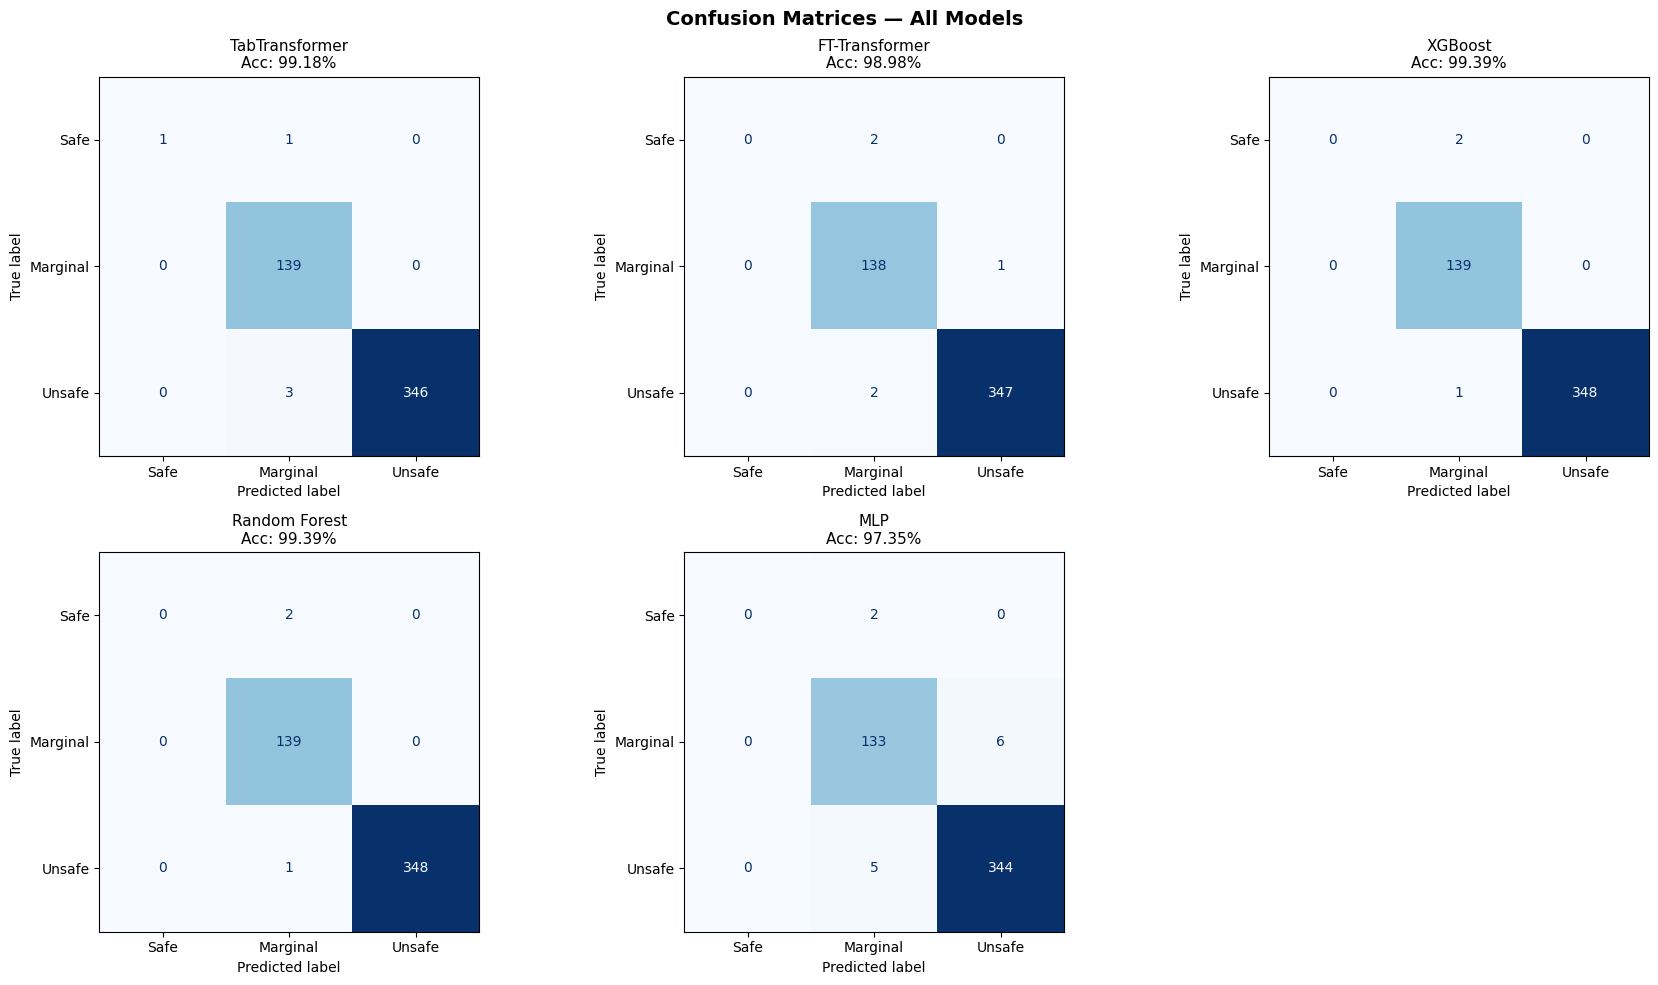

In [28]:
# ── Confusion matrices all 5 models ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (preds, labels)) in enumerate(all_models.items()):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Marginal', 'Unsafe'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    acc  = accuracy_score(labels, preds) * 100
    axes[i].set_title(f'{name}\nAcc: {acc:.2f}%', fontsize=11)

axes[-1].set_visible(False)  # hide empty 6th subplot
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ── Print winner ──────────────────────────────────────────────
top_row    = comparison_df.iloc[0]
transformer_rows = comparison_df[comparison_df['Type'] == 'Transformer']
best_transformer = transformer_rows.iloc[0]
best_baseline    = comparison_df[comparison_df['Type'] == 'Baseline'].iloc[0]

print(f'🏆 Overall Best     : {top_row["Model"]} ({top_row["Accuracy"]}%)')
print(f'🔵 Best Transformer : {best_transformer["Model"]} ({best_transformer["Accuracy"]}%)')
print(f'🔴 Best Baseline    : {best_baseline["Model"]} ({best_baseline["Accuracy"]}%)')
gap = best_transformer['Accuracy'] - best_baseline['Accuracy']
if gap > 0:
    print(f'✅ Transformer beats best baseline by {gap:.2f}% — novelty validated!')
else:
    print(f'⚠️  Baseline leads by {abs(gap):.2f}% — consider tuning Transformer epochs/lr')

🏆 Overall Best     : XGBoost (99.39%)
🔵 Best Transformer : TabTransformer (99.18%)
🔴 Best Baseline    : XGBoost (99.39%)
⚠️  Baseline leads by 0.21% — consider tuning Transformer epochs/lr


---
## Stage 10 — SHAP Explainability

We use `shap.DeepExplainer` for PyTorch models.
Background = small random sample of training data.
SHAP values tell which features pushed prediction towards Unsafe.

In [30]:
# ── SHAP via GradientExplainer (works with Transformer attention) ─────────────
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return F.softmax(self.model(x), dim=1)

wrapped_model = ModelWrapper(best_model).to(DEVICE)
wrapped_model.eval()

# Background — 100 random training samples
bg_idx  = np.random.choice(len(X_train_sc), size=100, replace=False)
bg_data = torch.tensor(X_train_sc[bg_idx], dtype=torch.float32).to(DEVICE)

# Test tensor — first 200 samples
X_test_tensor = torch.tensor(X_test_sc[:200], dtype=torch.float32).to(DEVICE)

print('⏳ Computing SHAP values via GradientExplainer...')
explainer   = shap.GradientExplainer(wrapped_model, bg_data)
shap_values = explainer.shap_values(X_test_tensor)

print('✅ SHAP values computed!')
print(f'   Number of classes : {len(shap_values)}')
print(f'   Per-class shape   : {shap_values[0].shape}')

⏳ Computing SHAP values via GradientExplainer...
✅ SHAP values computed!
   Number of classes : 3
   Per-class shape   : (200, 17)


📊 SHAP Summary — Feature importance for Unsafe class:


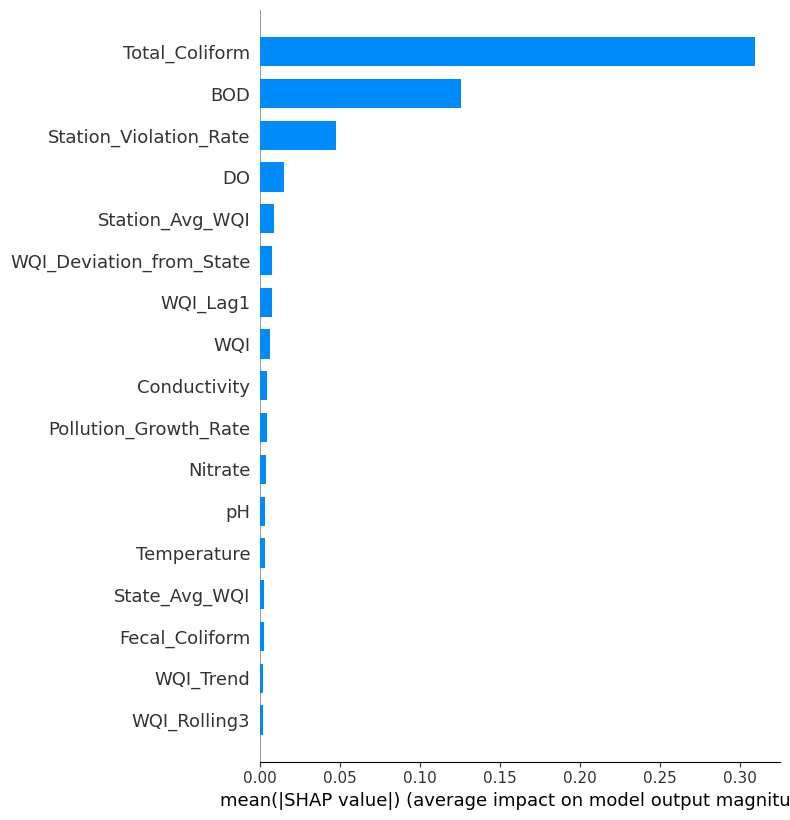

In [31]:
# ── SHAP Summary Bar Plot — Unsafe class ──────────────────────────────────────
X_test_df = pd.DataFrame(X_test_sc[:200], columns=FEATURE_COLS)

print('📊 SHAP Summary — Feature importance for Unsafe class:')
shap.summary_plot(
    shap_values[2],
    X_test_df,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=True
)

📊 SHAP Beeswarm — Direction of impact on Unsafe class:


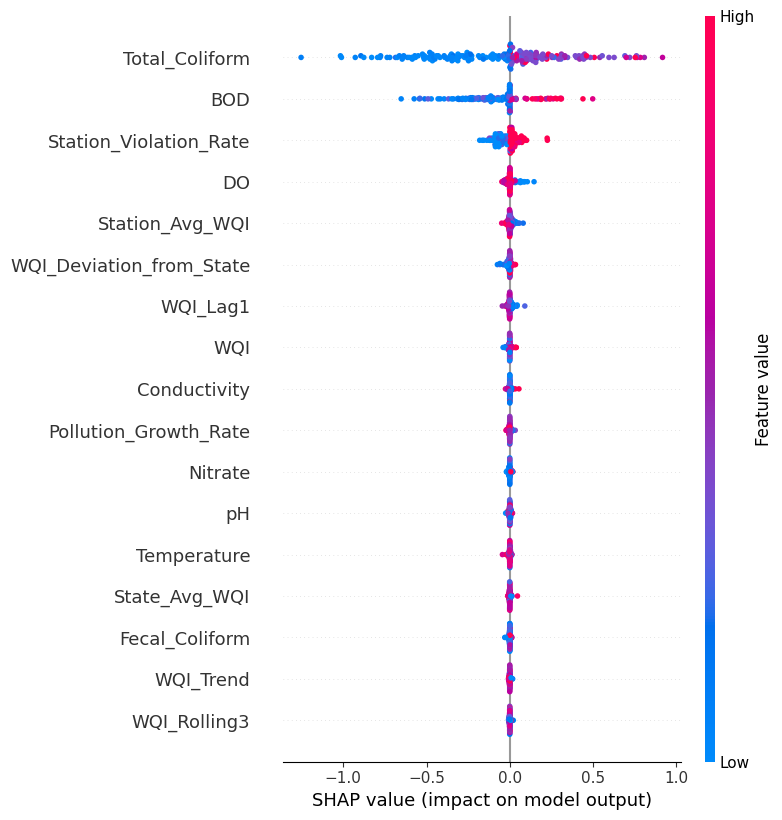

In [32]:
# ── SHAP Beeswarm Plot ────────────────────────────────────────────────────────
print('📊 SHAP Beeswarm — Direction of impact on Unsafe class:')
shap.summary_plot(
    shap_values[2],
    X_test_df,
    feature_names=FEATURE_COLS,
    show=True
)

📋 Explaining Test Sample #1
   Actual    : Unsafe
   Predicted : Unsafe
   P(Safe)=0.00  P(Marginal)=0.00  P(Unsafe)=1.00


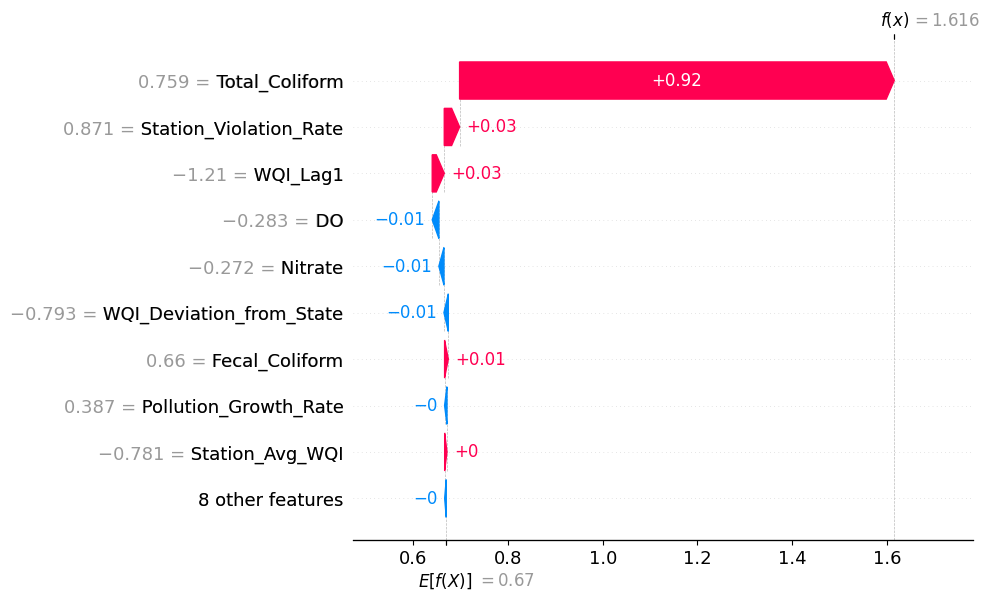

In [33]:
# ── SHAP Waterfall — single unsafe sample explanation ─────────────────────────
unsafe_indices = np.where(best_preds[:200] == 2)[0]

if len(unsafe_indices) > 0:
    idx = unsafe_indices[0]
    print(f'📋 Explaining Test Sample #{idx}')
    print(f'   Actual    : {CLASS_NAMES[y_true[idx]]}')
    print(f'   Predicted : {CLASS_NAMES[best_preds[idx]]}')
    print(f'   P(Safe)={best_proba[idx,0]:.2f}  '
          f'P(Marginal)={best_proba[idx,1]:.2f}  '
          f'P(Unsafe)={best_proba[idx,2]:.2f}')

    # Compute base value = mean model output on background for Unsafe class
    with torch.no_grad():
        bg_out     = wrapped_model(bg_data).cpu().numpy()
    base_val   = float(bg_out[:, 2].mean())

    shap_exp = shap.Explanation(
        values        = shap_values[2][idx],
        base_values   = base_val,
        data          = X_test_df.iloc[idx].values,
        feature_names = FEATURE_COLS,
    )
    shap.waterfall_plot(shap_exp, show=True)
else:
    print('No Unsafe predictions in first 200 test samples.')

---
## Stage 11 — Confidence Estimation (Bootstrapping)

In [34]:
# ── Bootstrap confidence with best model architecture ────────────────────────
N_BOOTSTRAP = 30   # 30 models (PyTorch trains slower than XGBoost)
SAMPLE_FRAC = 0.8
bootstrap_preds = np.zeros((N_BOOTSTRAP, len(X_test_sc)), dtype=int)

print(f'⏳ Running {N_BOOTSTRAP} bootstrap models (may take 5-10 mins)...')

for i in range(N_BOOTSTRAP):
    # Random sample with replacement
    idx_boot = np.random.choice(len(X_train_sc),
                                size=int(len(X_train_sc) * SAMPLE_FRAC),
                                replace=True)

    # Ensure all 3 classes present
    attempts = 0
    while len(np.unique(y_train_raw[idx_boot])) < 3 and attempts < 10:
        idx_boot = np.random.choice(len(X_train_sc),
                                    size=int(len(X_train_sc) * SAMPLE_FRAC),
                                    replace=True)
        attempts += 1

    X_boot = X_train_sc[idx_boot]
    y_boot = y_train_raw[idx_boot]

    boot_ds     = WaterDataset(X_boot, y_boot)
    boot_loader = DataLoader(boot_ds, batch_size=64, shuffle=True)

    # Create fresh model of same type as winner
    if best_name == 'FT-Transformer':
        boot_model = FTTransformer(N_FEATURES, N_CLASSES, dim=64,
                                   n_heads=8, n_layers=6).to(DEVICE)
    else:
        boot_model = TabTransformer(N_FEATURES, N_CLASSES, dim=64,
                                    n_heads=8, n_layers=4).to(DEVICE)

    # Quick train — 20 epochs per bootstrap
    opt  = AdamW(boot_model.parameters(), lr=3e-4, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    boot_model.train()
    for _ in range(20):
        for Xb, yb in boot_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(boot_model(Xb), yb)
            loss.backward()
            opt.step()

    # Predict
    boot_model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
        bootstrap_preds[i] = boot_model(X_t).argmax(1).cpu().numpy()

    if (i + 1) % 5 == 0:
        print(f'   Bootstrap {i+1}/{N_BOOTSTRAP} done')

print('✅ Bootstrapping complete!')

majority_pred = mode(bootstrap_preds, axis=0, keepdims=True).mode[0]
confidence    = np.mean(bootstrap_preds == majority_pred, axis=0) * 100

print(f'\n📊 Confidence Statistics:')
print(f'   Mean : {confidence.mean():.1f}%')
print(f'   Min  : {confidence.min():.1f}%')
print(f'   Max  : {confidence.max():.1f}%')

⏳ Running 30 bootstrap models (may take 5-10 mins)...
   Bootstrap 5/30 done
   Bootstrap 10/30 done
   Bootstrap 15/30 done
   Bootstrap 20/30 done
   Bootstrap 25/30 done
   Bootstrap 30/30 done
✅ Bootstrapping complete!

📊 Confidence Statistics:
   Mean : 99.0%
   Min  : 53.3%
   Max  : 100.0%


---
## Stage 12 — Final Output & Save

In [35]:
# ── Build final results dataframe ─────────────────────────────────────────────
# Compute SHAP for ALL test samples (not just 200)
print('⏳ Computing SHAP for full test set...')
X_test_all_tensor = torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
shap_values_all   = explainer.shap_values(X_test_all_tensor)
print('✅ SHAP done for full test set!')

test_df_reset = test_df.reset_index(drop=True)

results_df = test_df_reset[[
    'Year', 'Station_Code', 'Station_Name',
    'State', 'Water_Body_Type', 'WQI', 'WQI_Category'
]].copy()

results_df['Actual_Class']    = pd.Series(y_true).map(CLASS_NAMES).values
results_df['Predicted_Class'] = pd.Series(best_preds).map(CLASS_NAMES).values
results_df['P_Safe']          = best_proba[:, 0].round(3)
results_df['P_Marginal']      = best_proba[:, 1].round(3)
results_df['P_Unsafe']        = best_proba[:, 2].round(3)
results_df['Confidence_Pct']  = confidence.round(1)
results_df['Model_Used']      = best_name

# Top pollutant from full SHAP
shap_unsafe_abs             = np.abs(shap_values_all[2])
top_pollutant_idx           = np.argmax(shap_unsafe_abs, axis=1)
results_df['Top_Pollutant'] = [FEATURE_COLS[i] for i in top_pollutant_idx]

print('✅ Results dataframe built!')
print(f'   Shape: {results_df.shape}')
results_df.head(10)

⏳ Computing SHAP for full test set...
✅ SHAP done for full test set!
✅ Results dataframe built!
   Shape: (490, 15)


,Year,Station_Code,Station_Name,State,Water_Body_Type,WQI,WQI_Category,Actual_Class,Predicted_Class,P_Safe,P_Marginal,P_Unsafe,Confidence_Pct,Model_Used,Top_Pollutant
0,2023,1215,"THUMMALA CHERUVU, NASAMPET (V&M), WARANGAL",TELANGANA,LAKE,90.87,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,TabTransformer,Total_Coliform
1,2023,1263,"ELANGABEEL SYSTEM (CONNECTED TO R. KOLONG), ASSAM",ASSAM,LAKE,88.71,Good,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,Total_Coliform
2,2023,1285,"PICHOLA LAKE AT UDAIPUR (WATER INTAKE POINT), ...",RAJASTHAN,LAKE,90.46,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,TabTransformer,Total_Coliform
3,2023,1286,UDAISAGAR LAKE AT UDAIPUR (INTAKE PT.) RAJASTHAN,RAJASTHAN,LAKE,89.07,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,TabTransformer,Total_Coliform
4,2023,1291,GOBINDSAGAR LAKE D/S OF BILASPUR TOWN,HIMACHAL PRADESH,LAKE,117.91,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,Total_Coliform
5,2023,1297,"HARIKE LAKE AT HARIKE VILLAGE, PUNJAB",PUNJAB,LAKE,119.65,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,Total_Coliform
6,2023,1309,DAL LAKE AT SRINAGAR,JAMMU & KASHMIR,LAKE,126.06,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,Total_Coliform
7,2023,1343,"KANKORIA LAKE AT AHMEDABAD, NR. BALVATIKA,",GUJARAT,LAKE,210.95,Very Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,Total_Coliform
8,2023,1344,"CHANDOLA LAKE AT AHMEDABAD,",GUJARAT,LAKE,164.78,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,TabTransformer,BOD
9,2023,1345,"AJWAH LAKE AT SRI SAYAJI SABVAR, BARODA,",GUJARAT,LAKE,112.02,Poor,Marginal,Marginal,0.00,1.00,0.00,100.00,TabTransformer,Total_Coliform


In [36]:
# ── Save outputs ──────────────────────────────────────────────────────────────
# Excel predictions
results_df.to_excel('Water_Quality_Predictions_2023.xlsx', index=False)
df.to_excel('Water_Quality_Full_Engineered.xlsx', index=False)

# Save both model weights
torch.save(tab_model.state_dict(), 'tab_transformer.pt')
torch.save(ft_model.state_dict(),  'ft_transformer.pt')

# Save scaler + metadata as pickle (for dashboard use)
model_data = {
    'best_model_name' : best_name,
    'feature_cols'    : FEATURE_COLS,
    'class_names'     : CLASS_NAMES,
    'scaler'          : scaler,
    'bis_thresholds'  : BIS,
    'wqi_limits'      : WQI_LIMITS,
    'n_features'      : N_FEATURES,
    'n_classes'       : N_CLASSES,
    'tab_config'      : {'dim':64,'n_heads':8,'n_layers':4,'ffn_dim':256,'dropout':0.1},
    'ft_config'       : {'dim':64,'n_heads':8,'n_layers':6,'ffn_dim':256,'dropout':0.1},
}

with open('water_quality_transformer_meta.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('✅ All files saved!')
print('   Water_Quality_Predictions_2023.xlsx')
print('   Water_Quality_Full_Engineered.xlsx')
print('   tab_transformer.pt')
print('   ft_transformer.pt')
print('   water_quality_transformer_meta.pkl')

✅ All files saved!
   Water_Quality_Predictions_2023.xlsx
   Water_Quality_Full_Engineered.xlsx
   tab_transformer.pt
   ft_transformer.pt
   water_quality_transformer_meta.pkl


In [37]:
# ── Final summary ─────────────────────────────────────────────────────────────
total      = len(results_df)
n_safe     = (results_df['Predicted_Class'] == 'Safe').sum()
n_marginal = (results_df['Predicted_Class'] == 'Marginal').sum()
n_unsafe   = (results_df['Predicted_Class'] == 'Unsafe').sum()

# Top pollutant from full SHAP (already computed above)
shap_unsafe_abs   = np.abs(shap_values_all[2])
top_pollutant_idx = np.argmax(shap_unsafe_abs, axis=1)
results_df['Top_Pollutant'] = [FEATURE_COLS[i] for i in top_pollutant_idx]

print('=' * 60)
print('   SMART WATER QUALITY MONITORING — FINAL SUMMARY')
print('=' * 60)
print(f'   Best Model         : {best_name}')
print(f'   TabTransformer Acc : {tab_acc*100:.2f}%')
print(f'   FT-Transformer Acc : {ft_acc*100:.2f}%')
print(f'   Total Stations     : {total}')
print(f'   ✅ Safe            : {n_safe} ({n_safe/total*100:.1f}%)')
print(f'   ⚠️  Marginal        : {n_marginal} ({n_marginal/total*100:.1f}%)')
print(f'   🚨 Unsafe          : {n_unsafe} ({n_unsafe/total*100:.1f}%)')
print(f'   Avg WQI            : {results_df["WQI"].mean():.1f}')
print(f'   Mean Confidence    : {confidence.mean():.1f}%')
print('\n🚨 Top Pollutants (Unsafe stations):')
top = (results_df[results_df['Predicted_Class'] == 'Unsafe']['Top_Pollutant']
       .value_counts().head(5))
for p, c in top.items():
    print(f'   {p:<30}: {c} stations')
print('=' * 60)
print('✅ Pipeline complete!')
print('=' * 60)

   SMART WATER QUALITY MONITORING — FINAL SUMMARY
   Best Model         : TabTransformer
   TabTransformer Acc : 99.18%
   FT-Transformer Acc : 98.98%
   Total Stations     : 490
   ✅ Safe            : 1 (0.2%)
   ⚠️  Marginal        : 143 (29.2%)
   🚨 Unsafe          : 346 (70.6%)
   Avg WQI            : 105.5
   Mean Confidence    : 99.0%

🚨 Top Pollutants (Unsafe stations):
   Total_Coliform                : 222 stations
   BOD                           : 108 stations
   Station_Violation_Rate        : 11 stations
   DO                            : 4 stations
   WQI_Lag1                      : 1 stations
✅ Pipeline complete!
